In [1]:
import os
os.chdir('../')

In [2]:
from ecc.ecv import *
from ecc.nt import quad_rec, primesBetween

In [3]:
def iso_deg2_ab(ab,p=None):
    a,b = ab
    return ((-2*a)%p,(a*a-4*b)%p) if p else (-2*a,a*a-4*b)

def j_inv_ab2_model(ab,p):
    a,b = ab
    jnum = 256*((a*a-3*b)**3)
    jden = (a*a-4*b)*(b**2)
    return (jnum*pow(jden,-1,p))%p

def sqrt3m4(a,p):
    if p % 4 != 3:
        raise ValueError("p must be congruent to 3 mod 4")
    return pow(a,(p+1)//4,p)

def solve_quad_3m4(ab,p):
    a,b = ab
    if quad_rec(a*a-4*b,p) != 1:
        return []
    sqrt_disc = sqrt3m4(a*a-4*b,p)
    r1 = ((-a + sqrt_disc)*pow(2,-1,p))%p
    r2 = ((-a - sqrt_disc)*pow(2,-1,p))%p
    return [r1,r2]

def ab0_to_other_models_3m4(ab0,p):
    rts = solve_quad_3m4(ab0,p)
    newmodels = []
    for i in [0,1]:
        r0 = rts[i]
        r1 = rts[1-i]
        newa = (2*r0-r1)%p
        newb = (r0**2-r0*r1)%p
        newmodels.append((newa%p,newb%p))
    return newmodels

def ab_qr(ab,p):
    a,b = ab
    return quad_rec(a*a-4*b,p)

def isograph2_p7m8(p):
    if p % 8 != 7:
        raise ValueError("p must be congruent to 7 mod 8")
    c1models = [(0,-1)]
    c2models = [(0,1)]
    ab1 = (-6,1)
    while j_inv_ab2_model(ab1,p) != 1728%p:
        loopcheck = 0
        c1models.append(ab1)
        newmodels = [iso_deg2_ab(ab,p) for ab in ab0_to_other_models_3m4(ab1,p)]
        for ab2 in newmodels:
            if ab_qr(ab2,p)==1:
                ab1 = ab2
                loopcheck+=1
            else:
                c2models.append(ab2)
        if loopcheck == 0:
            raise ValueError("Loop check failed, no new model found")
    return c1models,c2models

In [6]:
def qf_to_str(abc):
    a,b,c = abc
    s = 'x^2'
    if a > 1:
        s = str(a)+s
    if b > 0:
        if b == 1:
            s+= '+x'
        else:
            s+=f'+{b} x'
    elif b < 0:
        if b == -1:
            s+='-x'
        else:
            s+=f'-{-b} x '
    s+=f'+ {c}'
    return s

def abcoefs_to_str(ab,p):
    a,b = ab
    j = j_inv_ab2_model(ab,p)
    g = 3*a*(2*a*a-9*b)
    qr = quad_rec(g,p)
    s = f'{j} ({p})'
    if qr == 1:
        return s+',+1'
    elif qr == 0:
        return s
    else:
        return s+',-1'

In [7]:
def iso2labels7m8(p):
    abs1,abs2 = isograph2_p7m8(p)
    return [abcoefs_to_str(ab,p) for ab in abs1],[abcoefs_to_str(ab,p) for ab in abs2]

In [8]:
cycle1p_test,cycle2p_test = iso2labels7m8(71)

In [47]:
cycle1p_test

['24(71)',
 '17(71),+1',
 '40(71),-1',
 '48(71),+1',
 '48(71),-1',
 '40(71),+1',
 '17(71),-1']

In [9]:
cycle1_test = qf_iso_cycle(class_group_id(-71),2)
cycle2_test = [qf_isogenies_down(qf,2)[0] for qf in cycle1_test]

In [34]:
import networkx as nx
import matplotlib.pyplot as plt
import math

def draw_double_cyclic_graph(inner_labels, outer_labels, title = None, filename=None):
    """
    Draw two concentric cyclic graphs with matching edges between them.

    Parameters:
        inner_labels (list of str)
        outer_labels (list of str)
        filename (str, optional)
    """
    assert len(inner_labels) == len(outer_labels), "Lists must have equal length"
    n = len(inner_labels)

    G = nx.Graph()

    # Add nodes
    for label in inner_labels:
        G.add_node(("inner", label))
    for label in outer_labels:
        G.add_node(("outer", label))

    # Add cycle edges (inner)
    for i in range(n):
        G.add_edge(("inner", inner_labels[i]),
                   ("inner", inner_labels[(i+1) % n]))
        
    # Add "spokes" between corresponding vertices
    for i in range(n):
        G.add_edge(("inner", inner_labels[i]),
                   ("outer", outer_labels[i]))

    # Positions: two concentric circles
    pos = {}
    for i in range(n):
        angle = 2 * math.pi * i / n

        # Inner circle (radius 1)
        pos[("inner", inner_labels[i])] = (math.cos(angle), math.sin(angle))

        # Outer circle (radius 2)
        pos[("outer", outer_labels[i])] = (1.8 * math.cos(angle), 1.8 * math.sin(angle))

    # Draw
    plt.figure(figsize=(7,7))

    nx.draw_networkx_edges(G, pos)

    # Draw labels with boxes (this replaces nodes visually)
    inner_labels_dict = {("inner", l): l for l in inner_labels}
    outer_labels_dict = {("outer", l): l for l in outer_labels}

    nx.draw_networkx_labels(
        G, pos,
        labels=inner_labels_dict,
        font_size=10,
        bbox=dict(facecolor="lightblue", edgecolor="black", boxstyle="round,pad=0.3")
    )

    nx.draw_networkx_labels(
        G, pos,
        labels=outer_labels_dict,
        font_size=10,
        bbox=dict(facecolor="lightgreen", edgecolor="black", boxstyle="round,pad=0.3")
    )

    plt.axis("off")

    if title:
        plt.title(title)

    if filename:
        plt.savefig(filename, bbox_inches="tight")
    else:
        plt.show()

    plt.close()



In [36]:
abc_to_tau_str((1,1,18))

'(-1+ √-71)/2'

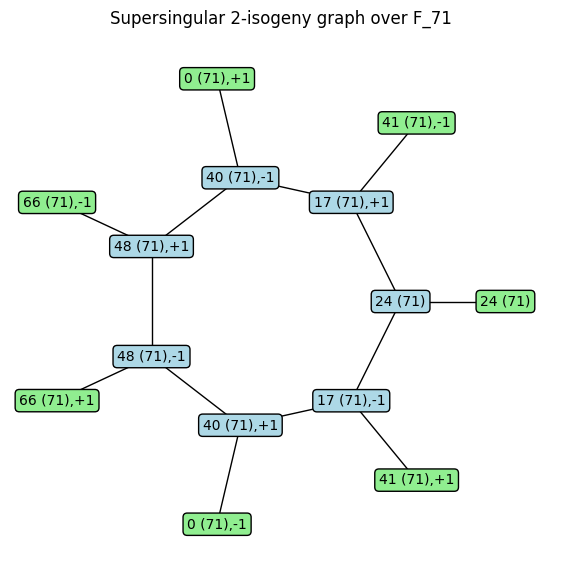

In [35]:
draw_double_cyclic_graph(cycle1p_test,cycle2p_test,title='Supersingular 2-isogeny graph over F_71')

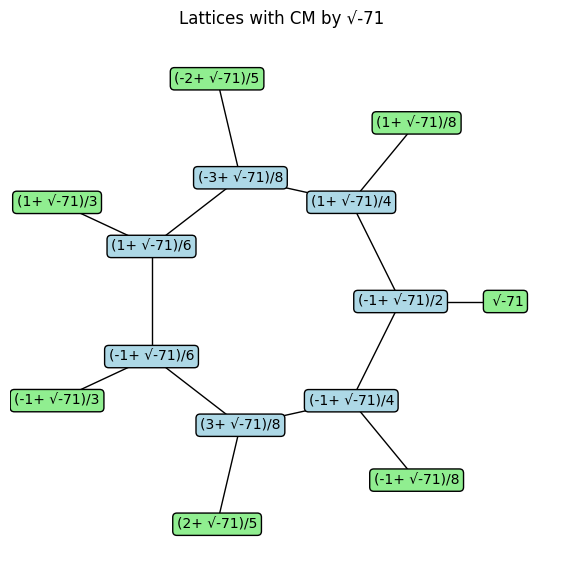

In [37]:
draw_double_cyclic_graph([abc_to_tau_str(qf) for qf in cycle1_test],[abc_to_tau_str(qf) for qf in cycle2_test],'Lattices with CM by √-71')

In [32]:
js71strC1 = ["-3.14*10^11", "744 - 560040.6 i", "30.2 + 380.1 i", "4155.4-5858.6 i", 
"4155.4 + 5858.6 i", "30.2 - 380.1 i","744 + 560040.6i"]
js71strC2 = [
    '9.83*10^22', '1457.7 + 303.3i', '-31362.1 + 23320.6i', '-(2.31 +4i)10^7',
      '-(2.31 -4i)10^7', '-31362.1 - 23320.6i', '1457.7 - 303.3i'
]

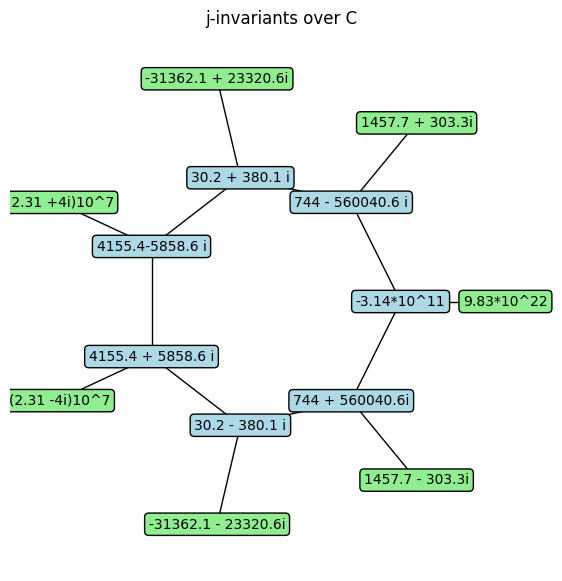

In [38]:
draw_double_cyclic_graph(js71strC1,js71strC2, 'j-invariants over C')